# <img style="float: left; padding-right: 20px; width: 200px" src="https://raw.githubusercontent.com/raxlab/imt2200-data/main/media/logo.jpg">  IMT 2200 - Introducción a Ciencia de Datos
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Semestre 2025-S2**<br>
**Profesor:** Rodrigo A. Carrasco <br>

# <h1><center>Tarea 03: Exploración de datos </center></h1>

**Fecha de Entrega:** 28 de octubre de 2025, a las 23:59.

**Fecha de publicación**: 14 de octubre de 2025.

**Formato de entrega:** Notebook ejecutado y comentado (`.ipynb`) en el módulo de Tarea 03 habilitado en Canvas.

## Instrucciones

- Esta Tarea debe desarrollarse de manera totalmente *individual*, de acuerdo a lo establecido en la sección de Integridad Académica en el programa del curso.
- La Tarea debe ser desarrollada en lenguaje de programación Python y la entrega en formato Jupyter Notebook.
- El desarrollo del Notebook debe ser claro y ordenado, incluyendo anotaciones (markdown) y comentarios que permitan seguir fácilmente el código y los pasos implementados a los correctores, y siguiendo buenas prácticas de programación. La presentación y claridad del notebook y código forman parte de la evaluación de la tarea.
- Notebook **autocontenible** que:
   - Ejecute sin errores todas las celdas.
  - Contenga tanto el código como los comentarios y explicaciones necesarias.
  - Incluya visualizaciones claras y correctamente etiquetadas.
- No se aceptarán notebooks con celdas rotas o que dependan de rutas externas no indicadas en la tarea.

- Deben hacer sus consultas y comentarios sobre la Tarea a través del canal de Tareas en el Foro del curso en Canvas.

---

## 1. Objetivos

- Aplicar los conceptos iniciales de manejo de datos y análisis exploratorio vistos en clases.
- Practicar la lectura, limpieza y manipulación de datos en Python.
- Desarrollar habilidades para visualizar y describir patrones y tendencias en conjuntos de datos reales.
- Fomentar la capacidad de comunicar resultados de forma clara y fundamentada.

### 1.1 Objetivo educacional

Esta Tarea tiene como objetivo que los estudiantes desarrollen la capacidad de manejar algunas de las librerías centrales para el desarrollo de Ciencia de Datos, con foco en la lectura y exploración de datos. 

Para los ejercicios a continuación, usted deberá leer, inspeccionar, manipular y graficar conjuntos de datos en distintos formatos, de manera de responder las preguntas de cada parte de la Tarea.

### 1.2 Pregunta de ciencia de datos

En esta tarea vamos a analizar la distribución de vulneribilidad escolar para distintos establecimientos educacionales en Chile, desde enseñanza parvularia hasta enseñanza media. Específicamente, queremos entender cómo se comporta un índice de vulnerabilidad en relación a variables como ruralidad, tipo de dependencia y comuna del establecimiento.

---

## 2. Datos

En este estudio, trabajaremos con los resultados publicados anualmente sobre por la JUNAEB
sobre vulnerabilidad de establecimientos educacionales en todo el territorio nacional. Estos resultados están disponibles en la siguiente página web:

* Índices de Vulnerabilidad (JUNAEB): https://www.junaeb.cl/medicion-la-vulnerabilidad-ivm/

Adicionalmente, para visualizar las variables, utilizaremos los mapas vectoriales que disponibiliza la Biblioteca del Congreso Nacional (BCN):

* Mapoteca BCN: https://www.bcn.cl/siit/mapas_vectoriales/index_html

### 2.1 Descarga de datos y conceptos generales (1 punto)

Acceda a los links entregados y descargue el set de datos del **Índice de Vulnerabilidad Multidimensional de Establecimientos Educacionales** para el año 2025. Este debería ser un documento XLSX con múltiples pestañas, incluyendo entre estas un índice que describe las columnas presentes en la base de datos.
Descargue además los archivos correspondientes a la **División comunal: polígonos de las comunas de Chile**. Este se descarga en formato `.zip` y contiene archivos shapefile para visualizar las comunas del país.

Investigue sobre este índice y responda de manera concisa: 
* ¿En qué consiste el IVM? ¿Qué rango de valores toma y qué significan? 
* ¿Cómo se obtiene el IVM de un establecimiento educacional?



Respuesta:

## 3. Lectura y limpieza de datos (1 punto)

### 3.1 Datos de establecimientos (0.5 puntos)
El archivo descargado contiene información sobre establecimientos de cuatro tipos: Parvularia, Primer Ciclo Básica, Segundo Ciclo Básica y Media.
Cargue los datos de los establecimientos en cuatro DataFrames distintos.

Revise cada uno de sus sets de datos y haga un proceso de limpieza si lo considera necesario (manejo de valores nulos, duplicados, inválidos, transformación de tipos de datos, etc). De haberlos, identifique qué atributos son categóricos y transforme los tipos de columna de acuerdo a su decisión, mostrando todos los posibles valores de cada categoría.

Justifique **todas** sus decisiones, **incluso** si decide no realizar una limpieza o transformación.

Finalmente, responda:

* a. ¿Cuántos establecimientos tiene cada set de datos?
* b. ¿Cuánto espacio en memoria ocupan en total los 4 datasets?
* c. ¿Cuántos estudiantes fueron evaluados en todo el país para cada nivel de enseñanza para el año 2025?


Primero los imports:

In [101]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

Se leen los sheets:

In [138]:
path="data/IVM_Establecimientos_2025-2.xlsx"

dfp= pd.read_excel(
    path,
    sheet_name="Parvularia")

dfc1 = pd.read_excel(
    path,
    sheet_name="1º Ciclo Básico")

dfc2 = pd.read_excel(
    path,
    sheet_name="2º Ciclo Básico")

dfm = pd.read_excel(
    path,
    sheet_name="Media")




Se empieza la limpieza:

In [139]:
dataframes=[dfp, dfc1, dfc2, dfm]
sheetnames=["Parvularia","1º Ciclo Básico","2º Ciclo Básico","Media"]

for df in dataframes:
    if df.isnull().sum().sum() != 0:
        print(f'Is null:{df.isnull().sum()}')
    if df.duplicated().sum() != 0:
        print(f'Duplicado{df.duplicated().sum()}')

Vemos que no hay valores nulos ni filas duplicadas así que no se hace ninguna limpieza.

a.- Como no hay datos repetidos, y como cada fila representa un establecimientos, la cantidad de establecimentos es igual a la cantidad de filas:

In [29]:
for df , sn in zip(dataframes,sheetnames):
    print(f'{sn} {len(df)}')

Parvularia 6163
1º Ciclo Básico 7082
2º Ciclo Básico 5662
Media 2618


b.- 

In [36]:
for df , sn in zip(dataframes,sheetnames):
    print(f'{sn} {round(df.memory_usage(deep=True).sum()/(1024**2), 2)} MB')

Parvularia 2.46 MB
1º Ciclo Básico 2.92 MB
2º Ciclo Básico 2.0 MB
Media 0.93 MB


c.- 'N EVALUADO' es el numero de estudiantes evaluado: se confirma que sean tipo int para poder sumarlos

In [40]:
for df in dataframes:
    print(df['N EVALUADO'].info())

<class 'pandas.core.series.Series'>
RangeIndex: 6163 entries, 0 to 6162
Series name: N EVALUADO
Non-Null Count  Dtype
--------------  -----
6163 non-null   int64
dtypes: int64(1)
memory usage: 48.3 KB
None
<class 'pandas.core.series.Series'>
RangeIndex: 7082 entries, 0 to 7081
Series name: N EVALUADO
Non-Null Count  Dtype
--------------  -----
7082 non-null   int64
dtypes: int64(1)
memory usage: 55.5 KB
None
<class 'pandas.core.series.Series'>
RangeIndex: 5662 entries, 0 to 5661
Series name: N EVALUADO
Non-Null Count  Dtype
--------------  -----
5662 non-null   int64
dtypes: int64(1)
memory usage: 44.4 KB
None
<class 'pandas.core.series.Series'>
RangeIndex: 2618 entries, 0 to 2617
Series name: N EVALUADO
Non-Null Count  Dtype
--------------  -----
2618 non-null   int64
dtypes: int64(1)
memory usage: 20.6 KB
None


In [42]:
for df , sn in zip(dataframes,sheetnames):
    print(f'{sn} {df['N EVALUADO'].sum()} alumnos evaluados')

Parvularia 255506 alumnos evaluados
1º Ciclo Básico 882881 alumnos evaluados
2º Ciclo Básico 484540 alumnos evaluados
Media 901899 alumnos evaluados


### 3.2 Datos geográficos (0.5 puntos)

Cargue en un GeoDataFrame de GeoPandas la información de los polígonos de cada comuna del país.

Como realizamos en la Tarea pasada, puede transformar el Coordinate Reference System (CRS) a EPSG 4326, para tener la información de los puntos de los polígonos con latitud y longitud.

In [176]:

agg_comunal= gpd.read_file("data/Comunas.zip")
agg_comunal=agg_comunal.to_crs(epsg=4326)
#comunas_gpd.plot(figsize=(50,50))

agg_comunal.head()
#print(agg_comunal.geom_type.head())

,objectid,shape_leng,dis_elec,cir_sena,cod_comuna,codregion,st_area_sh,st_length_,Region,Comuna,Provincia,geometry
0,48,170038.624165,16,8,6204,6,9.685774e+08,206184.271675,Región del Libertador Bernardo O'Higgins,Marchigüe,Cardenal Caro,"POLYGON ((-71.80071 -34.20728, -71.79992 -34.2..."
1,29,125730.104795,15,8,6102,6,4.157446e+08,151911.576827,Región del Libertador Bernardo O'Higgins,Codegua,Cachapoal,"POLYGON ((-70.35293 -33.95263, -70.35243 -33.9..."
2,30,63026.084422,15,8,6103,6,1.448565e+08,76355.326122,Región del Libertador Bernardo O'Higgins,Coinco,Cachapoal,"POLYGON ((-70.90058 -34.23703, -70.90063 -34.2..."
3,31,89840.903562,15,8,6104,6,3.256572e+08,108874.623150,Región del Libertador Bernardo O'Higgins,Coltauco,Cachapoal,"POLYGON ((-71.02492 -34.17053, -71.0232 -34.17..."
4,78,122626.493264,23,11,9121,9,6.990727e+08,156680.410681,Región de La Araucanía,Cholchol,Cautín,"POLYGON ((-72.95898 -38.46877, -72.95797 -38.4..."


## 4. Análisis descriptivo (1.5 puntos)

En esta sección haremos una exploración preliminar de los 4 sets de datos cargados. Para cada una de las siguientes preguntas, sustente su respuesta con al menos un gráfico y su análisis respectivo.

**Recomendación:** puede utilizar el método `subplots()` de `matplotlib.pyplot` para facilitar la visualización de múltiples gráficos a la vez.

### 4.1 Ruralidad (0.8 pts)
* a. ¿Cuál es la cantidad de establecimientos rurales vs urbanos según nivel de enseñanza?
* b. ¿Cómo se distribuye el IVM según nivel de enseñanza y ruralidad?


a.- Si queremos ver los porcentajes:

In [ ]:

for df , sn in zip(dataframes,sheetnames):
    print(f'{sn}:')
    cantidades=df['DS_RURALIDAD'].value_counts()
    print(f'{round(cantidades['Urbano']*100/len(df),2)}% Urbano')
    print(f'{round(cantidades['Rural']*100/len(df),2)}% Rural\n')

Parvularia:
79.56% Urbano
20.44% Rural

1º Ciclo Básico:
58.29% Urbano
41.71% Rural

2º Ciclo Básico:
73.65% Urbano
26.35% Rural

Media:
93.54% Urbano
6.46% Rural



Si queremos graficarlo usando las cantidades netas:

In [ ]:
for df , sn in zip(dataframes, sheetnames):
    df['Nivel']=sn


df_unificado= pd.concat(dataframes)


<Axes: xlabel='Nivel', ylabel='Cantidad'>

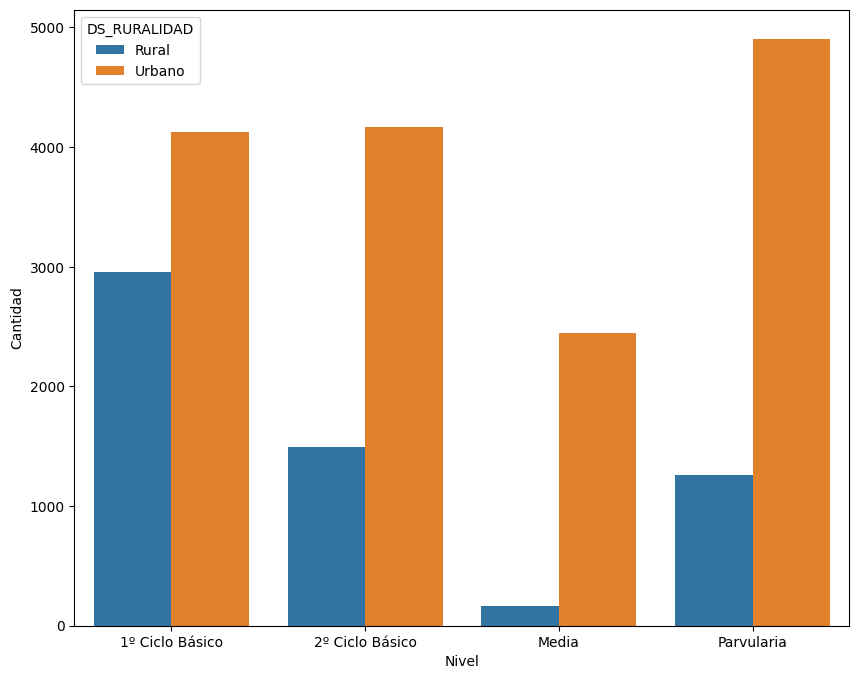

In [118]:
dfu_plot = df_unificado.groupby(['Nivel', 'DS_RURALIDAD']).size().reset_index(name='Cantidad')
plt.figure(figsize=(10,8))

sns.barplot(data=dfu_plot,
            x='Nivel',
            y='Cantidad',
            hue='DS_RURALIDAD')

b.-

<Axes: xlabel='Nivel', ylabel='IVM Establecimiento'>

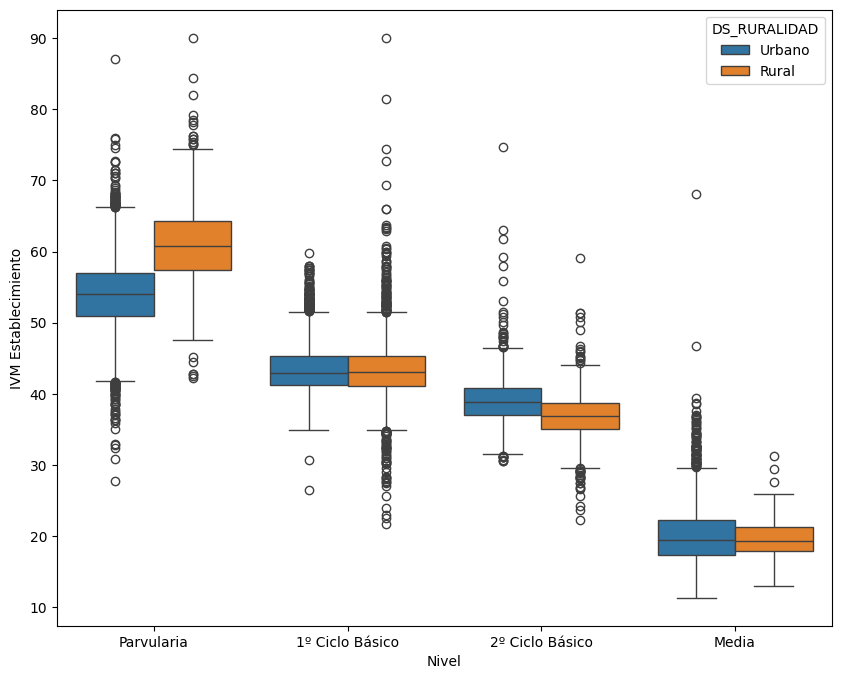

In [115]:

plt.figure(figsize=(10,8))

sns.boxplot(data=df_unificado,
            x='Nivel',
            y="IVM Establecimiento",
            hue='DS_RURALIDAD')

#### Respuesta escrita de 4.1b

por la mendia podemos notar que los establecimientos urbamos tienen el IVM un poco más alto pero no significativamente, excepto en el caso de los parvulos, donde la difereicia es mayor y son los establecimientos rurales los que tiene mayor IVM

### 4.2 Tipo de establecimiento (0.7 pts)

* ¿Cómo es la distribución del IVM promedio de los establecimientos según tipo de dependencia y nivel de enseñanza? 

<Axes: xlabel='Nivel', ylabel='Promedio'>

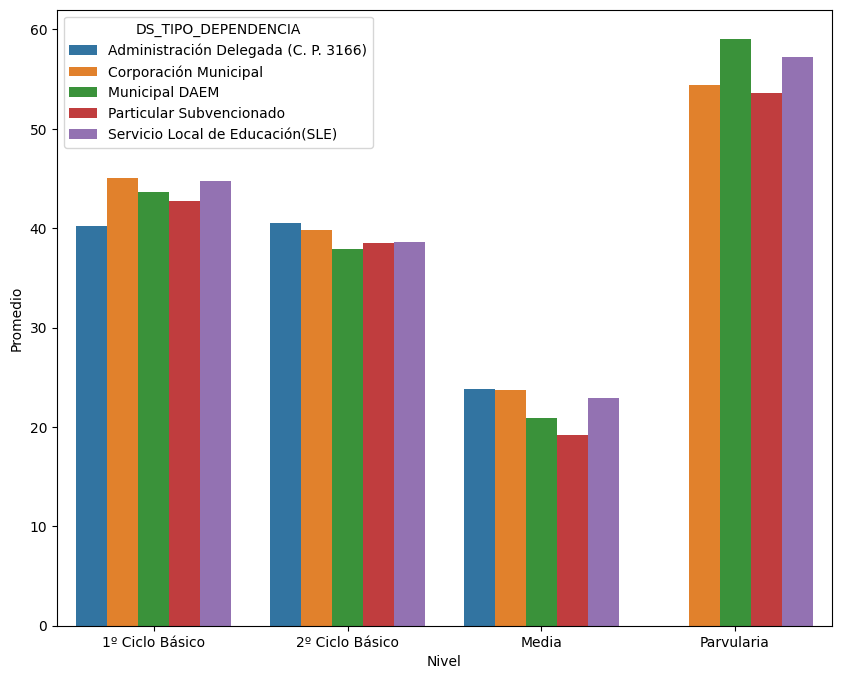

In [ ]:
dfu_plot2=df_unificado.groupby(['DS_TIPO_DEPENDENCIA','Nivel'])['IVM Establecimiento'].mean().reset_index(name='Promedio')
plt.figure(figsize=(10,8))

"""sns.barplot(data=dfu_plot2,
            x='Nivel',
            y='Promedio',
            hue='DS_TIPO_DEPENDENCIA')"""

Respuesta y comentarios:

### 4.3 Pregunta Bono: Dimensiones de vulnerabilidad (1 punto)

Para los niveles de enseñanza Parvularia y Básica Primer ciclo (1-4º), tenemos información sobre distintas dimensiones de que se utilizan para calcular el IVM, como condición socioeconómica familiar y comunal, salud, etc. 

* Para todo Chile, en promedio, ¿cuál es la dimensión con mayor puntaje de IVM para cada uno de estos dos niveles de enseñanza?

In [ ]:

dfc1=dfc1.rename(columns={'IVM Familia': 'IVM Familiar','IVM CSE Familia':'IVM CSE Familiar' })

dfp=dfp.rename(columns={'IVM Familia': 'IVM Familiar'})

IVM_C1=dfc1[['IVM Discapacidad','IVM Educación','IVM Salud',
            'IVM CSE Familiar','IVM CSE Comunal','IVM Familiar',
            'IVM Habitabilidad','IVM Participación']]

IVM_P=dfp[['IVM Estimulación y Apoyo','IVM Derechos',
            'IVM Salud','IVM CSE Familiar',
            'IVM CSE Comunal','IVM Familiar']]


print(f'{IVM_C1.mean().idxmax()} : {IVM_C1[IVM_C1.mean().idxmax()].mean()}')
print(f'{IVM_P.mean().idxmax()} : {IVM_P[IVM_P.mean().idxmax()].mean()}')

IVM CSE Familiar : 54.39076164533438
IVM Familiar : 70.66708502390739


Respuesta y comentarios:

## 5. Agrupación de bases de datos (2 puntos)

El objetivo de esta sección será agrupar los establecimientos según la comuna en la que se encuentran para obtener un resumen general sobre la vulnerabilidad escolar en cada una de ellas. Al finalizar esta sección, tendremos un nuevo DataFrame `agg_comunal` que contenga, al menos, la siguiente información:

* Comuna (nombre y ID)
* Región (ID)
* Cantidad de establecimientos rurales de la comuna
* Cantidad de establecimientos urbanos de la comuna
* Cantidad total de establecimientos de la comuna
* Porcentaje de establecimientos rurales
* IVM Promedio Parvularia de la comuna
* IVM Promedio Básica Primer Ciclo de la comuna
* IVM Promedio Básica Segundo Ciclo de la comuna
* IVM Promedio Media de la comuna
* Objeto geometry de GeoPandas correspondiente al polígono de la comuna respectiva

Armaremos este DataFrame paso a paso.

### 5.1 Cálculo de IVM promedio por comuna (0.8 pts)

Primero, para cada uno sus 4 DataFrames, calcule el promedio de la columna `IVM Establecimiento` según comuna. Almacene este valor en una nueva columna llamada `IVM Promedio {NIVEL DE ENSEÑANZA}` (por ejemplo, para enseñanza parvularia, cree la columna `IVM Promedio Parvularia`).

Junte los 4 resultados que obtuvo en un solo DataFrame `ivm_comunal` que contenga:
* Comuna (nombre y ID)
* Región (ID)
* IVM Promedio Parvularia de la comuna
* IVM Promedio Básica Primer Ciclo de la comuna
* IVM Promedio Básica Segundo Ciclo de la comuna
* IVM Promedio Media de la comuna

Ponga siempre atención al tamaño de sus DataFrames: como estamos agrupando comunalmente, estos siempre debiesen tener una cantidad de filas igual a las comunas de Chile.

In [178]:
lista_comunas=[]
for df , sn in zip(dataframes, sheetnames):
    gbtemp=df.groupby(['ID_REGION_ESTABLE', 'ID_COMUNA_ESTABLE', 'DS_COMUNA_ESTABLE'])['IVM Establecimiento'].mean().reset_index()
    gbtemp=gbtemp.rename(columns={'IVM Establecimiento': f'Promedio {sn} IVM','ID_REGION_ESTABLE':'ID_REGION',
                                'ID_COMUNA_ESTABLE': 'ID_COMUNA', 'DS_COMUNA_ESTABLE': 'COMUNA'})
    lista_comunas.append(gbtemp)

df_comunal=lista_comunas[0]
for df in lista_comunas[1:]:
    df_comunal=pd.merge(
        left=df_comunal,
        right=df,
        on=['ID_REGION','ID_COMUNA','COMUNA'],
        how='outer'
    )

df_comunal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345 entries, 0 to 344
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID_REGION                     345 non-null    int64  
 1   ID_COMUNA                     345 non-null    int64  
 2   COMUNA                        345 non-null    object 
 3   Promedio Parvularia IVM       338 non-null    float64
 4   Promedio 1º Ciclo Básico IVM  345 non-null    float64
 5   Promedio 2º Ciclo Básico IVM  344 non-null    float64
 6   Promedio Media IVM            335 non-null    float64
dtypes: float64(4), int64(2), object(1)
memory usage: 19.0+ KB


### 5.2 Establecimientos por comuna y ruralidad (0.8 pts)

Ahora contaremos la cantidad de establecimientos por comuna según ruralidad. Como buscamos la cantidad total de establecimientos, consideramos establecimientos de todos los niveles educacionales vistos. Para esto, combine los 4 DataFrames que cargó y genere un nuevo DataFrame `estab_comunal` que contenga:

* Comuna (ID)
* Cantidad de establecimientos rurales
* Cantidad de establecimientos urbanos
* Cantidad total de establecimientos
* Porcentaje de establecimientos rurales (Establecimientos rurales / Total establecimientos * 100)

Tenga en cuenta de que pueden aparecer establecimientos duplicados al combinar estos 4 DataFrames (por ejemplo, establecimientos que imparten múltiples niveles de enseñanza, desde 1º básico hasta 4º medio). Preocúpese de manejar estos casos antes de agrupar sus datos según ruralidad.

In [177]:
ruralidad_df= pd.crosstab(
                        index= df_unificado['ID_COMUNA_ESTABLE'],
                        columns= df_unificado['DS_RURALIDAD'],
                        margins=True
)
ruralidad_df['Total']=ruralidad_df['Rural']+ruralidad_df['Urbano']

ruralidad_df['Porcentaje_R']=ruralidad_df['Rural']*100/ruralidad_df['Total']
ruralidad_df['Porcentaje_U']=ruralidad_df['Urbano']*100/ruralidad_df['Total']

ruralidad_df.head()

DS_RURALIDAD,Rural,Urbano,All,Total,Porcentaje_R,Porcentaje_U
ID_COMUNA_ESTABLE,,,,,,
1101,10,179,189,189,5.291005,94.708995
1107,10,98,108,108,9.259259,90.740741
1401,28,0,28,28,100.000000,0.000000
1402,12,0,12,12,100.000000,0.000000
1403,7,0,7,7,100.000000,0.000000


### 5.3 Unión de bases de datos y polígonos (0.4 pts)

Finalmente, vamos a generar el DataFrame `agg_comunal` con la información de los dos previos DataFrames creados.
Combine la información de las dos secciones anteriores para crear su base de datos unificada. Por último, agregue la columna `geometry` con la información geográfica de cada comuna.

In [179]:
agg_comunal=pd.merge(
            left=agg_comunal,
            right=ruralidad_df,
            left_on='cod_comuna',
            right_on='ID_COMUNA_ESTABLE',
            how='outer'
)
agg_comunal.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 347 entries, 0 to 346
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   objectid      346 non-null    float64 
 1   shape_leng    346 non-null    float64 
 2   dis_elec      346 non-null    float64 
 3   cir_sena      346 non-null    float64 
 4   cod_comuna    346 non-null    object  
 5   codregion     346 non-null    float64 
 6   st_area_sh    346 non-null    float64 
 7   st_length_    346 non-null    float64 
 8   Region        346 non-null    object  
 9   Comuna        346 non-null    object  
 10  Provincia     346 non-null    object  
 11  geometry      346 non-null    geometry
 12  Rural         346 non-null    float64 
 13  Urbano        346 non-null    float64 
 14  All           346 non-null    float64 
 15  Total         346 non-null    float64 
 16  Porcentaje_R  346 non-null    float64 
 17  Porcentaje_U  346 non-null    float64 
dtypes:

In [180]:
agg_comunal=pd.merge(
            left=agg_comunal,
            right=df_comunal,
            left_on='cod_comuna',
            right_on='ID_COMUNA',
            how='outer'
)
agg_comunal.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 347 entries, 0 to 346
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   objectid                      346 non-null    float64 
 1   shape_leng                    346 non-null    float64 
 2   dis_elec                      346 non-null    float64 
 3   cir_sena                      346 non-null    float64 
 4   cod_comuna                    346 non-null    object  
 5   codregion                     346 non-null    float64 
 6   st_area_sh                    346 non-null    float64 
 7   st_length_                    346 non-null    float64 
 8   Region                        346 non-null    object  
 9   Comuna                        346 non-null    object  
 10  Provincia                     346 non-null    object  
 11  geometry                      346 non-null    geometry
 12  Rural                         346 non-null

## 6. Análisis de vulnerabilidad por comuna (1.5 puntos)

### 6.1 Mapa de calor (0.8 pts)

Genere mapas de calor de las comunas de Chile según el IVM promedio de los establecimientos educacionales. Realice esto para cada etapa de enseñanza (Parvularia, Básica 1, Básica 2 y Media). Analice y comente sus resultados:
* ¿Cómo se diferencia la vulnerabilidad en distintos sectores del país según nivel de enseñanza?

In [181]:
print(agg_comunal.geom_type.head())

0         Polygon
1    MultiPolygon
2         Polygon
3         Polygon
4         Polygon
dtype: object


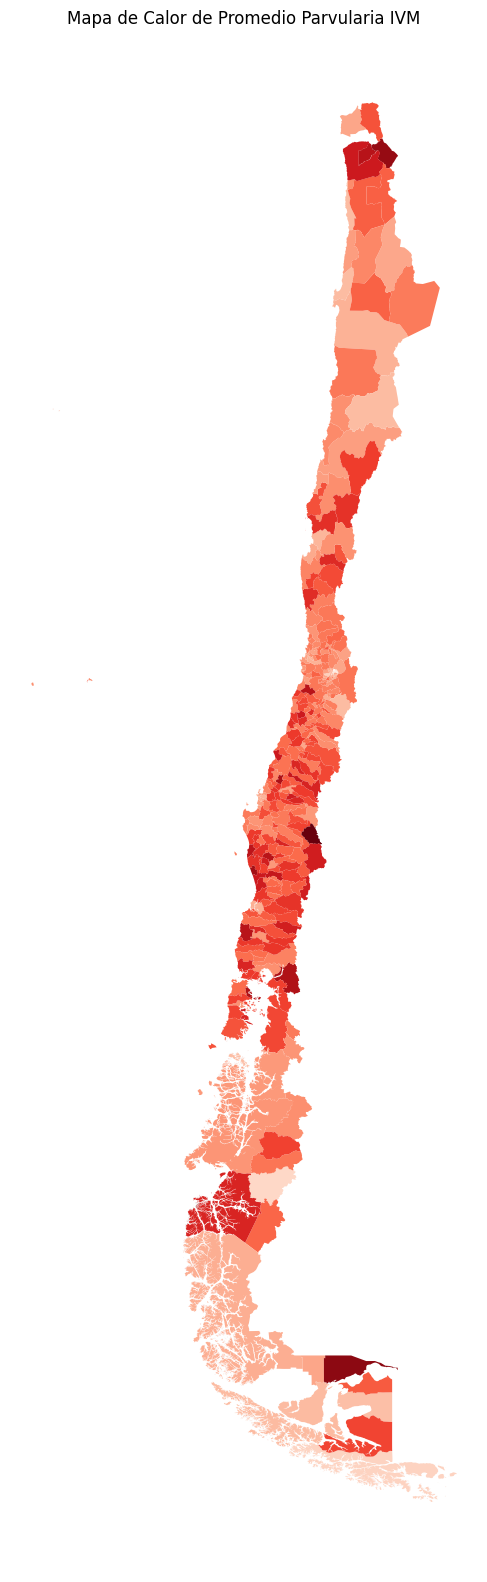

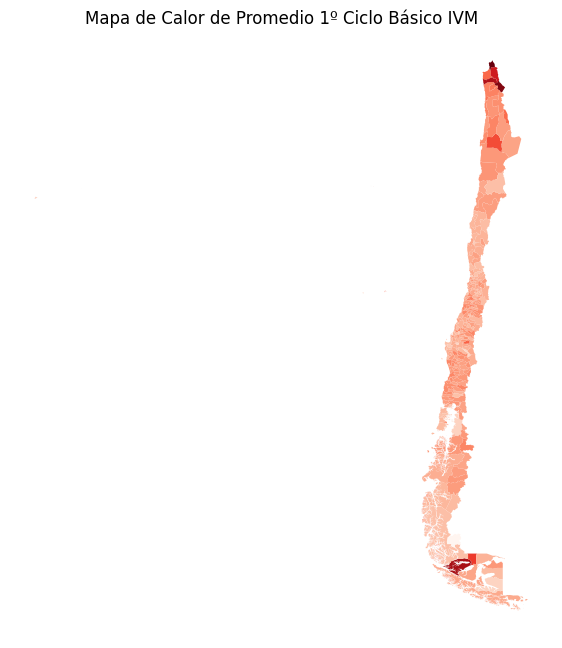

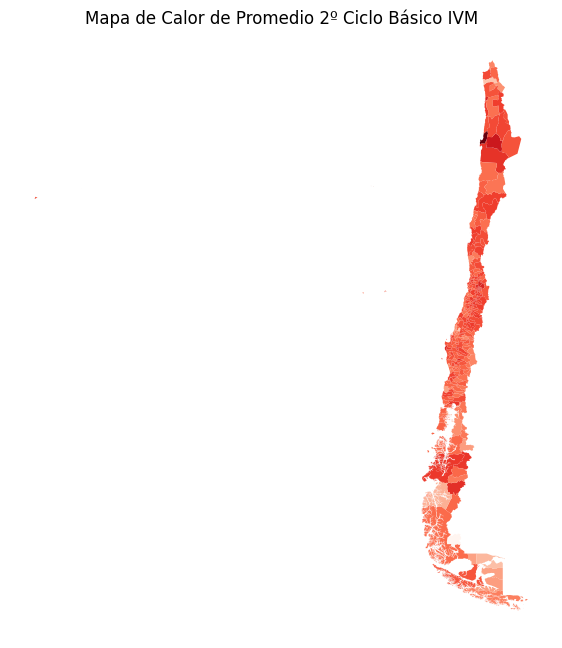

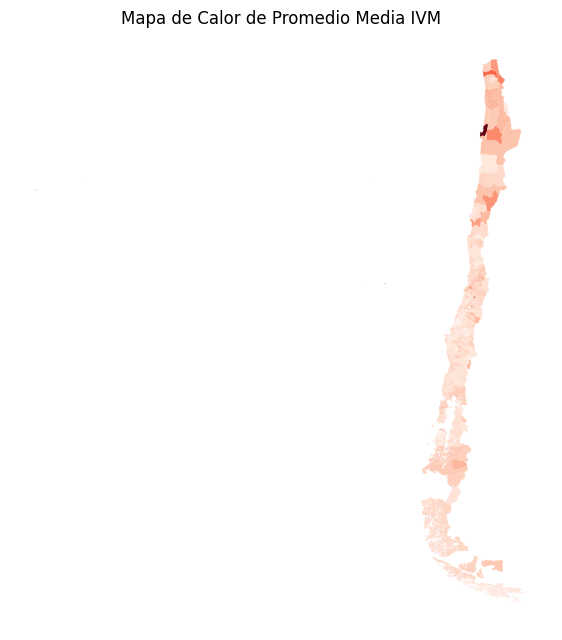

In [194]:
indices_IVM=['Promedio Parvularia IVM','Promedio 1º Ciclo Básico IVM',
            'Promedio 2º Ciclo Básico IVM','Promedio Media IVM']

for indice in indices_IVM:
    ax = agg_comunal.plot(
        column=indice,
        cmap='Reds',
        linewidth=0.5,
        figsize=(7,20)
    )
    ax.set_title(f'Mapa de Calor de {indice}',loc='center')
    ax.set_axis_off()
    plt.show()


Comentarios y análisis:

Podemos notar que en los establecimientos de Parvulo la vulnerabilidad es bastante en la mayoría de las regiones, siendo levemente mayor en en centro y en los extremos de chile, mientras que el primer ciclo de enseñanza basica y la enseñanza media tienen valores mucho menores, teniendo un mayor indice en el norte.
Por ultimo el segundo ciclio de enseñanza basica muestra mayor vulnerabilidad que los dos anteriores, teniendo como zona más vulnerable las comunas del notre.

### 6.2 Relación entre ruralidad comunal y vulnerabilidad (0.7 pts)

En la sección **5.2** definimos el **porcentaje de ruralidad** de cada comuna según la cantidad de establecimientos rurales en cada una. Analice y visualice los datos en `agg_comunal` para responder la siguiente pregunta:

* ¿Hay alguna correlación entre el IVM promedio y el porcentaje de ruralidad en las comunas de Chile?

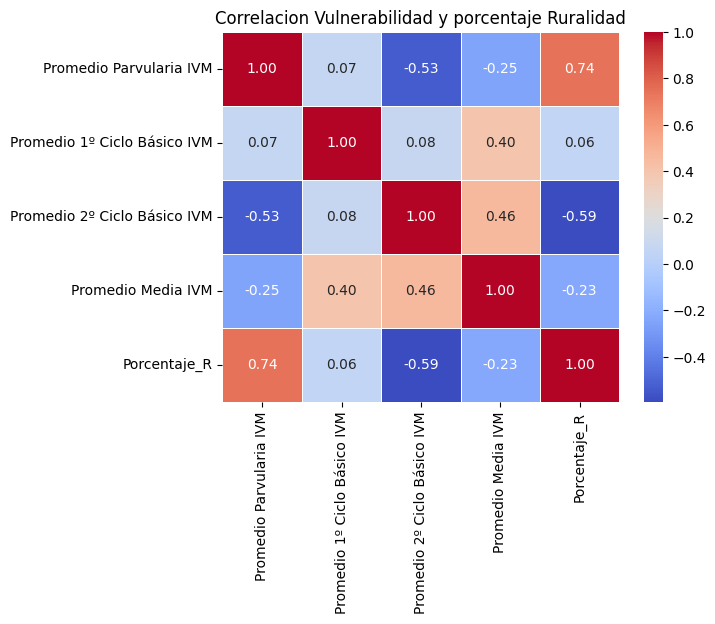

In [195]:
correlaciones=['Promedio Parvularia IVM','Promedio 1º Ciclo Básico IVM',
            'Promedio 2º Ciclo Básico IVM','Promedio Media IVM','Porcentaje_R']

corr= agg_comunal[correlaciones].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlacion Vulnerabilidad y porcentaje Ruralidad')
plt.show()

Podemos notar que la unica correlacion se puede encontrar con la vulnerabilidad de 
las istituciones parvularias, que lo podemos notar con el mapa georeferenciad.

## 7 Pregunta Bono (2 punto)

* Proponga una pregunta de análisis que le interese responder con los datos de cualquiera de las bases de datos leídas o generadas durante esta Tarea.
Respóndala de la misma forma que las preguntas anteriores, generando una o varias visualizaciones y analizando sus resultados. Justifique 

**Recomendación**: Trate de proponer una pregunta que justifique el uso de agregación de datos y visualización. En otras palabras, que
no pueda ser respondida directamente sin el uso de gráficos (por ejemplo, *"¿cuál es el establecimiento con mayor IVM?"* puede ser respondida con una búsqueda rápida en el DataFrame).

**Pregunta propuesta:**

In [ ]:
# respuesta